In [93]:
import pandas as pd
import numpy as np

In [94]:
df=pd.read_csv('dirty_dataset.csv')
df

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
0,12369,Hasan D.,200.0,35149,2023-05-30,SALES,Man,America,Sylhet,118.4,0,Good value for money.,219.18,NaN,0
1,7361,Grace P.,NaN,77836,2017-02-27,Engineering,FEMALE,America,Chittagong,71kg,True,Product met all expectations.,329.26,NaN,0
2,3446,Eve D.,20.0,35404,2022-01-18,hr,male,BANGLADESH,Chitagong,98.7,False,Very satisfied with the quality.,438.6,NaN,0
3,18416,Diana E.,47.0,107375,2017-04-15,Marketing,Male,U.K.,Khulna,NaN,false,Delivery was fast and packaging great.,238.03,NaN,0
4,13677,Ira W.,64.0,55962,2021-11-02,SALES,F,United Kingdom,Dhaka,83.5,false,Would buy again without hesitation.,9.4,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20295,19842,Frank N.,27.0,9999999,2010-06-21,engineering,Female,U.K.,Chittagong,93.7,False,Delivery was fast and packaging great.,$199.19,NaN,0
20296,1769,Frank N.,45.0,31616,2021-01-11,hr,F,U.K.,Khulna,NaN,False,Product met all expectations.,223.39,NaN,0
20297,9930,Hasan A.,30.0,70125,2013-07-07,Engineering,Woman,bd,Khulna,116.3,True,Would buy again without hesitation.,68.16,NaN,0
20298,3241,Frank D.,58.0,40120,2022-03-25,SALES,M,UK,Rajshahi,72.0,True,NaN,90.83,NaN,0


In [95]:
df.shape

(20300, 15)

In [96]:
df1=df.copy()

In [97]:
df.dtypes

employee_id              int64
name                    object
age                    float64
salary                  object
join_date               object
department              object
gender                  object
country                 object
city                    object
weight_kg               object
is_active               object
review                  object
price                   object
weight_kg_duplicate    float64
target                   int64
dtype: object

In [98]:
df.isnull().sum()

employee_id                0
name                       0
age                      621
salary                   610
join_date                810
department               857
gender                  1632
country                  608
city                     604
weight_kg                643
is_active                586
review                  1465
price                    446
weight_kg_duplicate    20300
target                     0
dtype: int64

## Task 01: Missing Values (NaN, Empty Strings)

**Problem:**  
A column may have missing values (NaN or empty strings).

These missing values create issues in data visualization.

In [99]:
df.isnull().sum()

employee_id                0
name                       0
age                      621
salary                   610
join_date                810
department               857
gender                  1632
country                  608
city                     604
weight_kg                643
is_active                586
review                  1465
price                    446
weight_kg_duplicate    20300
target                     0
dtype: int64

In [100]:
df

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
0,12369,Hasan D.,200.0,35149,2023-05-30,SALES,Man,America,Sylhet,118.4,0,Good value for money.,219.18,NaN,0
1,7361,Grace P.,NaN,77836,2017-02-27,Engineering,FEMALE,America,Chittagong,71kg,True,Product met all expectations.,329.26,NaN,0
2,3446,Eve D.,20.0,35404,2022-01-18,hr,male,BANGLADESH,Chitagong,98.7,False,Very satisfied with the quality.,438.6,NaN,0
3,18416,Diana E.,47.0,107375,2017-04-15,Marketing,Male,U.K.,Khulna,NaN,false,Delivery was fast and packaging great.,238.03,NaN,0
4,13677,Ira W.,64.0,55962,2021-11-02,SALES,F,United Kingdom,Dhaka,83.5,false,Would buy again without hesitation.,9.4,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20295,19842,Frank N.,27.0,9999999,2010-06-21,engineering,Female,U.K.,Chittagong,93.7,False,Delivery was fast and packaging great.,$199.19,NaN,0
20296,1769,Frank N.,45.0,31616,2021-01-11,hr,F,U.K.,Khulna,NaN,False,Product met all expectations.,223.39,NaN,0
20297,9930,Hasan A.,30.0,70125,2013-07-07,Engineering,Woman,bd,Khulna,116.3,True,Would buy again without hesitation.,68.16,NaN,0
20298,3241,Frank D.,58.0,40120,2022-03-25,SALES,M,UK,Rajshahi,72.0,True,NaN,90.83,NaN,0


In [101]:
df['salary']=pd.to_numeric(df['salary'],errors='coerce')

In [102]:
df['salary']

0          35149.0
1          77836.0
2          35404.0
3         107375.0
4          55962.0
           ...    
20295    9999999.0
20296      31616.0
20297      70125.0
20298      40120.0
20299     114722.0
Name: salary, Length: 20300, dtype: float64

In [103]:
df['price']

0         219.18
1         329.26
2          438.6
3         238.03
4            9.4
          ...   
20295    $199.19
20296     223.39
20297      68.16
20298      90.83
20299     142.13
Name: price, Length: 20300, dtype: object

In [104]:
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [105]:
df['price']

0        219.18
1        329.26
2        438.60
3        238.03
4          9.40
          ...  
20295    199.19
20296    223.39
20297     68.16
20298     90.83
20299    142.13
Name: price, Length: 20300, dtype: float64

In [106]:
df['weight_kg']

0        118.4
1         71kg
2         98.7
3          NaN
4         83.5
         ...  
20295     93.7
20296      NaN
20297    116.3
20298     72.0
20299     74.0
Name: weight_kg, Length: 20300, dtype: object

In [107]:
df["weight_kg"] = (
    df["weight_kg"]
    .astype(str)
    .str.replace("kg", "", regex=False)
)

In [108]:
df["weight_kg"] = pd.to_numeric(df["weight_kg"], errors="coerce")

In [109]:
df["age"] = df["age"].fillna(df["age"].median())
df["salary"] = df["salary"].fillna(df["salary"].median())
df["price"] = df["price"].fillna(df["price"].median())
df["weight_kg"] = df["weight_kg"].fillna(df["weight_kg"].median())

In [110]:
df.isnull().sum()

employee_id                0
name                       0
age                        0
salary                     0
join_date                810
department               857
gender                  1632
country                  608
city                     604
weight_kg                  0
is_active                586
review                  1465
price                      0
weight_kg_duplicate    20300
target                     0
dtype: int64

In [111]:
df['department']

0              SALES
1        Engineering
2                 hr
3          Marketing
4              SALES
            ...     
20295    engineering
20296             hr
20297    Engineering
20298          SALES
20299             HR
Name: department, Length: 20300, dtype: object

In [112]:
df['department']=df['department'].fillna(df['department'].mode()[0])

In [113]:
df['department'].isnull().sum()

0

In [114]:
df['gender']

0           Man
1        FEMALE
2          male
3          Male
4             F
          ...  
20295    Female
20296         F
20297     Woman
20298         M
20299       Man
Name: gender, Length: 20300, dtype: object

In [115]:
df['gender']=df['gender'].fillna(df['gender'].mode()[0])

In [116]:
df['gender'].isnull().sum()

0

In [117]:
df['country']

0               America
1               America
2            BANGLADESH
3                  U.K.
4        United Kingdom
              ...      
20295              U.K.
20296              U.K.
20297                bd
20298                UK
20299                UK
Name: country, Length: 20300, dtype: object

In [118]:
df['country']=df['country'].fillna(df['country'].mode()[0])

In [119]:
df['country'].isnull().sum()

0

In [120]:
df['city']=df['city'].fillna(df['city'].mode()[0])

In [121]:
df.dtypes

employee_id              int64
name                    object
age                    float64
salary                 float64
join_date               object
department              object
gender                  object
country                 object
city                    object
weight_kg              float64
is_active               object
review                  object
price                  float64
weight_kg_duplicate    float64
target                   int64
dtype: object

In [122]:
df['join_date']

0        2023-05-30
1        2017-02-27
2        2022-01-18
3        2017-04-15
4        2021-11-02
            ...    
20295    2010-06-21
20296    2021-01-11
20297    2013-07-07
20298    2022-03-25
20299    2023-08-12
Name: join_date, Length: 20300, dtype: object

In [123]:
df["join_date"] = pd.to_datetime(
    df["join_date"],
    errors="coerce"
)


In [124]:
df["join_date"] = df["join_date"].fillna(df["join_date"].mode()[0])

In [125]:
df["review"] = df["review"].fillna("No Review")

In [126]:
df['is_active']

0            0
1         True
2        False
3        false
4        false
         ...  
20295    False
20296    False
20297     True
20298     True
20299    False
Name: is_active, Length: 20300, dtype: object

In [127]:
df["is_active"] = df["is_active"].map({
    "True":True,
    "False":False
})

In [128]:
df['is_active']=df['is_active'].fillna(False)

C:\Users\HP\AppData\Local\Temp\ipykernel_13720\4292727086.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_active']=df['is_active'].fillna(False)


In [129]:
df.isnull().sum()

employee_id                0
name                       0
age                        0
salary                     0
join_date                  0
department                 0
gender                     0
country                    0
city                       0
weight_kg                  0
is_active                  0
review                     0
price                      0
weight_kg_duplicate    20300
target                     0
dtype: int64

In [130]:
df.drop(columns=['weight_kg_duplicate'], inplace=True)

In [131]:
df.isnull().sum()

employee_id    0
name           0
age            0
salary         0
join_date      0
department     0
gender         0
country        0
city           0
weight_kg      0
is_active      0
review         0
price          0
target         0
dtype: int64


## Solutions

Drop rows

Drop columns

Mean Imputation

Median Imputation

Mode Imputation

Forward Fill

Backward Fill


## Task 02 :Duplicate Rows

**Problem:**

Same type rows consume memory which is bad and unnecessary for our analysis.

So, we have to drop duplicate rows.



In [132]:
df.duplicated().sum()

300

In [133]:
df[df.duplicated()]

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,target
1302,10364,Frank O.,24.0,112578.0,2010-09-10,HR,M,BD,Dhka,95.8,True,Delivery was fast and packaging great.,22.75,0
1834,16035,Hasan V.,53.0,-500.0,2017-03-01,Marketing,female,BANGLADESH,Chittagong,48.2,False,Product met all expectations.,385.13,0
2338,12369,Hasan D.,200.0,35149.0,2023-05-30,SALES,Man,America,Sylhet,118.4,False,Good value for money.,219.18,0
2469,13108,Diana V.,43.0,88859.0,2023-06-09,Marketing,Male,United States,Khulna,73.8,True,good,430.17,0
2784,7983,Grace G.,32.0,75294.0,2023-06-09,engineering,Man,U.K.,Khulna,60.2,True,"Excellent product, highly recommend!",237.72,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20110,13509,Charlie S.,34.0,106326.0,2016-06-20,Finace,Man,U.S.A,Slyhet,112.3,False,fine,340.03,0
20140,2388,Eve A.,35.0,98091.0,2017-04-22,SALES,M,America,Slyhet,90.4,False,Good value for money.,451.34,0
20154,2689,John O.,46.0,45615.0,2023-06-09,hr,F,usa,Rajshahi,118.0,False,Would buy again without hesitation.,341.28,0
20173,5188,Charlie J.,46.0,75294.0,2017-04-03,HR,Male,BANGLADESH,Chittagong,73.0,True,bad,419.32,0


In [134]:
df.drop_duplicates(inplace=True)

In [135]:
df1.shape

(20300, 15)

In [136]:
df.shape

(20000, 14)

In [137]:
df2=df.copy()

**Solutions:**

 Run df.duplicated().sum() to count duplicates.

 Preview duplicates: df[df.duplicated()]

 Remove duplicates: df.drop_duplicates(inplace=True)

 Verify: compare df.shape before and after.
 

Finally ,duplicate rows was no more

## Task 03 Duplicate IDs

**Problem**

In a particular column there might be duplicate rows.

It creates memory loss.



In [138]:
df['employee_id'].duplicated().sum()

199

In [139]:
df[df['employee_id'].duplicated(keep=False)]

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,target
29,250,Frank U.,56.0,90635.0,2013-05-12,Sales,male,Bangladesh,Dhaka,107.3,False,Would buy again without hesitation.,342.24,1
40,49,John L.,58.0,50810.0,2024-07-22,hr,FEMALE,U.K.,Dhakka,108.8,False,"Excellent product, highly recommend!",83.46,0
75,48,Ira E.,0.0,101013.0,2013-08-28,engineering,MALE,BD,Dhakka,115.0,False,Good value for money.,318.78,0
196,436,Charlie S.,29.0,54295.0,2020-08-27,Mrketing,M,us,Chittagongg,75.9,False,Product met all expectations.,265.25,0
270,86,Bob U.,36.0,61688.0,2023-06-09,engineering,M,bd,Sylhet,91.7,False,na,167.05,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20016,207,Bob M.,63.0,73657.0,2013-10-08,Mrketing,M,USA,Rajshahi,125.5,False,Very satisfied with the quality.,167.18,0
20072,435,Charlie U.,31.0,112727.0,2016-04-15,engineering,MALE,U.K.,Rajshahi,119.0,False,Good value for money.,242.44,0
20104,427,Frank U.,33.0,35686.0,2014-03-21,Mrketing,M,usa,Rajshahi,73.8,True,Good value for money.,396.43,0
20267,35,Eve L.,55.0,40160.0,2015-12-13,Finance,Male,U.K.,Dhaka,61.0,True,Very satisfied with the quality.,106.40,0


In [140]:
df.drop_duplicates(subset=['employee_id'], keep='first')

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,target
0,12369,Hasan D.,200.0,35149.0,2023-05-30,SALES,Man,America,Sylhet,118.4,False,Good value for money.,219.18,0
1,7361,Grace P.,41.0,77836.0,2017-02-27,Engineering,FEMALE,America,Chittagong,71.0,True,Product met all expectations.,329.26,0
2,3446,Eve D.,20.0,35404.0,2022-01-18,hr,male,BANGLADESH,Chitagong,98.7,False,Very satisfied with the quality.,438.60,0
3,18416,Diana E.,47.0,107375.0,2017-04-15,Marketing,Male,U.K.,Khulna,86.8,False,Delivery was fast and packaging great.,238.03,0
4,13677,Ira W.,64.0,55962.0,2021-11-02,SALES,F,United Kingdom,Dhaka,83.5,False,Would buy again without hesitation.,9.40,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20295,19842,Frank N.,27.0,9999999.0,2010-06-21,engineering,Female,U.K.,Chittagong,93.7,False,Delivery was fast and packaging great.,199.19,0
20296,1769,Frank N.,45.0,31616.0,2021-01-11,hr,F,U.K.,Khulna,86.8,False,Product met all expectations.,223.39,0
20297,9930,Hasan A.,30.0,70125.0,2013-07-07,Engineering,Woman,bd,Khulna,116.3,True,Would buy again without hesitation.,68.16,0
20298,3241,Frank D.,58.0,40120.0,2022-03-25,SALES,M,UK,Rajshahi,72.0,True,No Review,90.83,0


In [141]:
df['employee_id'] = range(1, len(df)+1)

In [142]:
assert df['employee_id'].duplicated().sum() == 0

**Solution**

 Count: df['employee_id'].duplicated().sum()

View: df[df['employee_id'].duplicated(keep=False)]

Option A: keep first occurrence — df.drop_duplicates(subset=['employee_id'], keep='first')

 Option B: assign new unique IDs — df['employee_id'] = range(1, len(df)+1)
 
 Verify: assert df['employee_id'].duplicated().sum() == 0



## Task 04: Wrong Date Formats

**Problem:**

5 mixed formats: YYYY-MM-DD, DD/MM/YYYY, MM-DD-YYYY, DD-Mon-YYYY

Because of this we can't find which was date ,which was month ,which was year.


In [143]:
df['join_date'].dtype

dtype('<M8[ns]')

## Solution

Check dtype: df['join_date'].dtype — will be object.

Convert: pd.to_datetime(df['join_date'], infer_datetime_format=True, errors='coerce')

errors='coerce' turns unrecognized formats into NaT.

Handle NaT values: fill with median date.

Standardize output: df['join_date'].dt.strftime('%Y-%m-%d')

Verify dtype: df['join_date'].dtype — should be datetime64.

Already this was done in the above.

## Task 05 :Numeric Stored as String

**Problem**

In this case ,we cannot do any mathematical operation if the numerical column is treated as string/obj.



In [144]:
df['salary'].dtype

dtype('float64')

In [145]:
df['weight_kg'].dtype

dtype('float64')

In [146]:
df['price'].dtype

dtype('float64')

## Already done above 

## Task 06 :Inconsistent Labels

**Problem**

Same name in different format may create unnecessary headache to us ,thus we must fix synonyms in one format.

In [147]:
df['country'].value_counts()

country
USA               2126
usa               1526
U.K.              1521
BD                1513
Bangladesh        1509
U.S.A             1503
us                1499
UK                1493
United States     1480
America           1479
BANGLADESH        1473
bd                1447
United Kingdom    1431
Name: count, dtype: int64

In [148]:
country_map={
    'USA':'United States',
    'us':'United States',
    'U.S.A':'United States',
    'usa':'United States',
    'America':'United States',
    'U.K.':'United Kingdom',
    'UK':'United Kingdom' ,
    'BD':'Bangladesh',
    'BANGLADESH':'Bangladesh',
    'bd':'Bangladesh'



}

In [149]:
df['country'] = df['country'].map(country_map).fillna(df['country'])

In [150]:
gender_map = {
    'm': 'Male',
    'male': 'Male',
    'f': 'Female',
    'female': 'Female',
    'man':'Male',
    'woman':'Female'
}

df['gender'] = df['gender'].str.lower().map(gender_map).fillna(df['gender'])

In [151]:
df['department']=df['department'].str.strip()

In [152]:
df['department'].unique()

array(['SALES', 'Engineering', 'hr', 'Marketing', 'Mrketing', 'Finace',
       'Sales', 'engineering', 'Finance', 'HR'], dtype=object)

In [153]:
df['department']=df['department'].str.title()

In [154]:
dept_map = {
    'Hr': 'HR',
    'Mrketing': 'Marketing',
    'Finace': 'Finance'
}

df['department'] = df['department'].replace(dept_map).fillna('Unknown')

In [155]:
df['country'].value_counts()

country
United States     9613
Bangladesh        5942
United Kingdom    4445
Name: count, dtype: int64

In [156]:
df['gender'].value_counts()

gender
Male      10897
Female     9103
Name: count, dtype: int64

In [157]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

## Data Cleaning (Standardization Process)

Affected columns: country, gender, department

## 1. Country Cleaning

**First inspect values:**

```python

df['country'].value_counts()

## 2. Gender Cleaning

Convert to lowercase first:

## 3. Department Cleaning

Normalize text:

4. Final Verification

## Task 07 Spelling Mistakes

** Problem:**

Typo errors (e.g., Mrketing -> Marketing, Finace ->Finance)

Inconsistent casing (e.g., hr, HR, Hr)

Extra spaces (e.g., "USA " instead of "USA")

Abbreviations vs full forms (e.g., us, USA, America -> United States)

Mixed formats in same column

Wrong or unclear labels

**Impact of these problems:** 

Incorrect grouping in analysis (wrong value_counts)

Wrong statistical results

Poor data quality

Model training performance decrease (ML tasks)

Duplicate categories for same meaning

In [158]:
df['city'].value_counts()

city
Khulna         4349
Rajshahi       3281
Sylhet         3227
Dhaka          3124
Chittagong     3113
Slyhet          514
Dhka            488
Rajshai         485
Chitagong       474
Chittagongg     473
Dhakka          472
Name: count, dtype: int64

In [159]:
city_fix = {
    'Dhka': 'Dhaka',
    'Dhakka': 'Dhaka',
    'Chitagong': 'Chittagong',
    'Chittagongg': 'Chittagong',
    'Slyhet': 'Sylhet',
    'Rajshai': 'Rajshahi'
}

In [160]:
df['city']=df['city'].replace(city_fix)


In [161]:
df['department'].value_counts()

department
Sales          4696
HR             3839
Marketing      3832
Engineering    3830
Finance        3803
Name: count, dtype: int64

In [162]:
df['city'].unique()

array(['Sylhet', 'Chittagong', 'Khulna', 'Dhaka', 'Rajshahi'],
      dtype=object)

## Solution Approach:

Standardize text using str.lower() / str.strip() / str.title()

Use mapping dictionary (.map() or .replace())

Handle missing or unmatched values using fillna()

Validate results using value_counts()

## Task 08 Outliers:

# Problems of Outliers in Data Analysis

Outliers are extreme values that are much higher or lower than most of the data points.

##  Main Problems Caused by Outliers:

### 1. Affects Mean (Average)

Outliers can heavily distort the mean, making it unrepresentative of the dataset.

### 2. Misleading Statistical Analysis

They can give wrong insights about the data distribution and trends.

### 3. Impacts Machine Learning Models

Models like Linear Regression are highly sensitive to outliers and may produce poor predictions.

### 4. Distorts Variance and Standard Deviation

Outliers increase spread, making data look more variable than it actually is.

### 5. Reduces Model Accuracy

Training performance decreases because the model tries to fit extreme values.

### 6. Skews Data Visualization

Graphs like boxplots and histograms become distorted and harder to interpret.

##  Conclusion:

Outliers should be detected and handled properly (using IQR, Z-score, or capping) to improve data quality and analysis accuracy.



In [163]:
df['salary'].describe()


count    2.000000e+04
mean     2.304954e+05
std      1.236135e+06
min     -5.000000e+02
25%      5.417725e+04
50%      7.529400e+04
75%      9.635250e+04
max      9.999999e+06
Name: salary, dtype: float64

<Axes: >

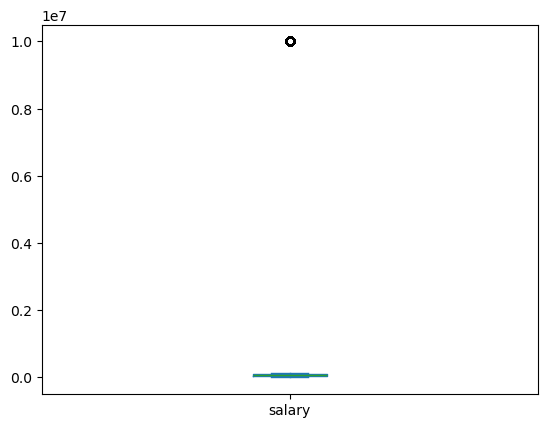

In [164]:
df['salary'].plot(kind='box')

In [165]:
import matplotlib.pyplot as plt

{'whiskers': [<matplotlib.lines.Line2D at 0x1d9def98680>,
 'caps': [<matplotlib.lines.Line2D at 0x1d9def99310>,
 'boxes': [<matplotlib.lines.Line2D at 0x1d9def93fe0>],
 'medians': [<matplotlib.lines.Line2D at 0x1d9def99dc0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1d9def9a0f0>],
 'means': []}

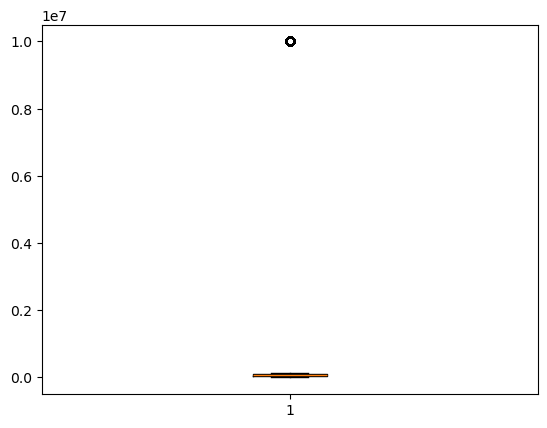

In [166]:
plt.boxplot(df['salary'])

In [167]:
Q1=df['salary'].quantile(0.25)
Q3=df['salary'].quantile(0.75)
IQR=Q3-Q1
lower=Q1 - 1.5*IQR
upper=Q3 + 1.5*IQR
outliers = df[
    (df["salary"] < lower) |
    (df["salary"] > upper)
]
# Cap
df["salary"] = df["salary"].clip(
    lower,
    upper
)




In [168]:
df['salary'].describe()

count     20000.000000
mean      75509.351356
std       27972.910143
min        -500.000000
25%       54177.250000
50%       75294.000000
75%       96352.500000
max      159615.375000
Name: salary, dtype: float64

## Solution:

**https://www.linkedin.com/feed/update/urn:li:share:7469937336978636800/**

Follow the link 

## Task 09 Invalid Values

**Problem**

Wrong predictions

If data contains invalid values, the model learns incorrect patterns.

Example:

Age = -10
Marks = 500

The model becomes confused.

Lower accuracy

Bad data reduces model performance and accuracy.

Training errors

Some algorithms cannot handle invalid text or impossible values

Bias in model
Invalid values can shift averages and distributions.

Example:

One invalid salary = 99999999

This changes mean and affects scaling.

Poor feature scaling

Out-of-range values disturb normalization and standardization.

Incorrect relationships

The model may learn fake correlations from wrong values.

Missing value creation

While cleaning invalid values, many values become NaN, which must be handled later.

Encoding problems

Wrong categorical values create extra unnecessary categories.

Example:

"Dhaka"
"dhaka"
"DHAKA"

ML treats them as different categories.

Overfitting risk

Noise from invalid values can make the model memorize bad patterns.

Visualization problems

Graphs and statistics become misleading because of incorrect values.

Example in Scikit-learn and Pandas.

In [169]:
df[(df['age']<18)|(df['age']>65)].shape

(391, 14)

In [170]:
df.loc[df['age']<18,'age']=np.nan

In [171]:
df.loc[df['age']>65,'age']=np.nan

In [172]:
df['age'].fillna(df['age'].median(),inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_13720\2790788646.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(),inplace=True)


In [173]:
df.loc[df['price']<0,'price']=np.nan

In [174]:
df['price'].fillna(df['price'].median(),inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_13720\50049080.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['price'].fillna(df['price'].median(),inplace=True)


In [176]:
assert ((df['age'] >= 18) & (df['age'] <= 65)).all()

## Solution

 Count invalid ages: df[(df['age'] < 18) | (df['age'] > 65)].shape

 Set invalid ages to NaN: df.loc[df['age'] < 18, 'age'] = np.nan

 df.loc[df['age'] > 65, 'age'] = np.nan

 Fill NaN with median: df['age'].fillna(df['age'].median(), inplace=True)

  Do the same for price: df.loc[df['price'] < 0, 'price'] = np.nan then fill.

Verify: assert (df['age'] >= 18).all() and (df['age'] <= 65).all()


## Task 10 Noisy Text (Reviews)

**Problem in simple words:**

Review text data is usually not clean. It contains noise (unwanted stuff) that makes ML/NLP models perform poorly.

 What “Noisy Text” includes:

Special characters

"good!!! "

"bad@@@"

Extra spaces

"this is good"

Mixed case

"GoOd", "BAD", "Nice"

Numbers inside text

"gr8 product", "h4ppy"

URLs and emails

"visit www.site.com"

"contact me@email.com"

Short forms / slang

"u" → you

"gr8" → great

Repeated letters

"sooooo good" → "so good"

Stopwords (optional removal)

"is, am, the, a, and"

 Why it is a problem?

Because ML models:

cannot understand messy text properly

learn wrong patterns

give low accuracy in sentiment analysis

In [177]:
df['review'].value_counts()

review
Delivery was fast and packaging great.    2792
Good value for money.                     2767
Product met all expectations.             2760
Excellent product, highly recommend!      2748
Would buy again without hesitation.       2725
Very satisfied with the quality.          2720
No Review                                 1442
ok                                         250
...                                        243
ok ok                                      235
bad                                        233
na                                         232
good                                       223
fine                                       220
.                                          217
not bad                                    193
Name: count, dtype: int64

In [178]:
noisy = ['ok', 'bad', 'na', 'n/a', '...', 'fine', 'not bad', 'ok ok', '.']

In [179]:
df['review']=df['review'].replace(noisy,np.nan)

In [180]:
df['review'].replace('', np.nan, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_13720\1357149749.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['review'].replace('', np.nan, inplace=True)


In [181]:
df['review'].fillna('No Review',inplace=True)

In [182]:
df['review'].str.split().str.len().value_counts()

review
4    8275
5    5445
2    3265
6    2792
1     223
Name: count, dtype: int64

## Solution

Inspect: df['review'].value_counts() to identify noisy values.

Define noisy list: noisy = ['ok','bad','na','n/a','...','fine','not bad','ok ok','.']

Replace noisy values: df['review'] = df['review'].replace(noisy, np.nan)

Also replace empty strings: df['review'].replace('', np.nan, inplace=True)

Fill NaN reviews with 'No Review'.

Verify: df['review'].str.split().str.len().value_counts() — check word count distribution.

## Task 11 Boolean as String

**Problems**

Boolean values are treated as text instead of real True/False values

Filtering conditions give wrong or empty results (e.g., "True" != True)

Logical operations (AND, OR, NOT) do not work properly

Counting True/False values becomes incorrect or unreliable

Machine learning models cannot directly use string booleans

Requires extra preprocessing and data cleaning steps

Mixed formats like "true", "TRUE", "yes", "no" create inconsistency

Increases noise and reduces data quality

Makes analysis slower and more error-prone

Can lead to incorrect insights and decisions

In [186]:
df['is_active'].unique()

array([False,  True])

In [184]:
true_vals=['True','true','TRUE','1',True,1]

In [ ]:
df['is_active']=df['is_active'].isin(true_vals)

In [187]:
df['is_active'].dtype

dtype('bool')

In [188]:
df['is_active'].value_counts()

is_active
False    12667
True      7333
Name: count, dtype: int64

## Solution:

Inspect: df['is_active'].unique() to see all unique values.

Define truthy set: true_vals = ['True','true','TRUE','1',True,1]

Convert: df['is_active'] = df['is_active'].isin(true_vals)

Or with lambda: df['is_active'] = df['is_active'].map(lambda x: str(x).lower() in ['true','1'])

Verify: df['is_active'].dtype — should be bool.

Check distribution: df['is_active'].value_counts()

## Task 12 Data Type Issues

**Problem**

Columns like salary, weight_kg, price are stored as object (string) instead of numeric types

Numeric operations (mean, sum, etc.) will fail or give wrong results

Date column join_date may be stored as string, so time-based analysis won’t work

Boolean column is_active may be stored as string/object, not real bool

Missing or invalid values may cause conversion errors

Wrong dtype leads to slow processing and incorrect analysis

In [189]:
df.dtypes

employee_id             int64
name                   object
age                   float64
salary                float64
join_date      datetime64[ns]
department             object
gender                 object
country                object
city                   object
weight_kg             float64
is_active                bool
review                 object
price                 float64
target                  int64
dtype: object

In [190]:
expected = {
    'employee_id': int,
    'age': float,
    'salary': float,
    'weight_kg': float,
    'price': float,
    'join_date': 'datetime',
    'is_active': bool
}

In [191]:
df['age'] = df['age'].astype(float)

In [192]:
df['join_date'] = pd.to_datetime(df['join_date'], errors='coerce')

In [193]:
df['is_active'] = df['is_active'].astype(bool)

In [194]:
df.dtypes

employee_id             int64
name                   object
age                   float64
salary                float64
join_date      datetime64[ns]
department             object
gender                 object
country                object
city                   object
weight_kg             float64
is_active                bool
review                 object
price                 float64
target                  int64
dtype: object

## Solution:

Inspect: df.dtypes to see all current data types.

Define expected types: expected = {'employee_id': int, 'age': float, 'salary': float, ...}

Cast columns: df['age'] = df['age'].astype(float)

join_date: df['join_date'] = pd.to_datetime(df['join_date'])

is_active: df['is_active'] = df['is_active'].astype(bool)

Verify: df.dtypes again — all columns should show correct types.

## Task 13 Range Violations

**Problem**

Dataset contains invalid values outside realistic ranges (e.g., age < 18 or > 65)

Such values are logically incorrect and reduce data quality

Numerical analysis (mean, median, etc.) becomes misleading

Models can get wrong patterns due to extreme values

Price or salary may contain outliers or data entry errors

Some records may be unusable without correction or removal

Range violations can affect business decisions and reporting accuracy

Without cleaning, results may not reflect real-world conditions

Data becomes inconsistent and unreliable for analysis

Visualization (charts, distributions) can get distorted by extreme values


In [195]:
ranges = {
    'age': (18, 65),
    'price': (0, 10000),
    'salary': (15000, 500000)
}

In [196]:
df[(df['age'] < 18) | (df['age'] > 65)].shape

(0, 14)

In [197]:
df.loc[(df['age'] < 18) | (df['age'] > 65), 'age'] = np.nan

In [198]:
df['age'] = df['age'].clip(18, 65)

In [199]:
# Price cleaning
df['price'] = df['price'].clip(0, 10000)

# Salary cleaning
df['salary'] = df['salary'].clip(15000, 500000)

In [200]:
(df['age'] >= 18).all() and (df['age'] <= 65).all()

True

In [201]:
df.describe()

,employee_id,age,salary,join_date,weight_kg,price,target
count,20000.000000,20000.000000,20000.000000,20000,20000.000000,20000.000000,20000.000000
mean,10000.500000,41.468300,75712.401356,2018-07-02 19:56:34.080000,87.035970,251.183999,0.049950
min,1.000000,18.000000,15000.000000,2010-01-01 00:00:00,45.000000,5.000000,0.000000
25%,5000.750000,30.000000,54177.250000,2014-07-23 00:00:00,67.000000,133.800000,0.000000
50%,10000.500000,41.000000,75294.000000,2019-01-12 12:00:00,86.800000,244.980000,0.000000
75%,15000.250000,53.000000,96352.500000,2023-06-09 00:00:00,107.300000,367.732500,0.000000
max,20000.000000,65.000000,159615.375000,2024-12-30 00:00:00,130.000000,499.970000,1.000000
std,5773.647028,13.520785,27472.185240,NaN,23.832058,139.596605,0.217847


## Solution

Define valid ranges: ranges = {'age': (18,65), 'price': (0, 10000), 'salary': (15000, 500000)}

Count violations: df[(df['age'] < 18) | (df['age'] > 65)].shape

Option A — set to NaN then fill: df.loc[df['age'] < 18, 'age'] = np.nan

Option B — clip: df['age'] = df['age'].clip(18, 65)

Apply same logic for price and salary.

Verify: (df['age'] >= 18).all() and (df['age'] <= 65).all()

## Task 14 Class Imbalance

**Problem**

Class imbalance occurs when one category appears much more frequently than others in a dataset. For example, suppose a dataset contains animal records where 70% are cows and only 20% are goats. Because the model sees cows much more often during training, it becomes biased toward predicting “cow” even when the input actually belongs to another class.

For instance, if we search for a goat and provide a feature like “has four legs,” the model may incorrectly predict it as a cow because it has learned that most four-legged animals in the dataset are cows. This happens because the dataset is dominated by cow examples, causing the model to favor the majority class.

As a result, minority classes such as goats are predicted less accurately, leading to biased and unreliable outcomes. Class imbalance can reduce model fairness and overall performance, especially when minority categories are important.



In [202]:
df['target'].value_counts()

target
0    19001
1      999
Name: count, dtype: int64

In [203]:
df['target'].value_counts(normalize=True)*100

target
0    95.005
1     4.995
Name: proportion, dtype: float64

<Axes: xlabel='target'>

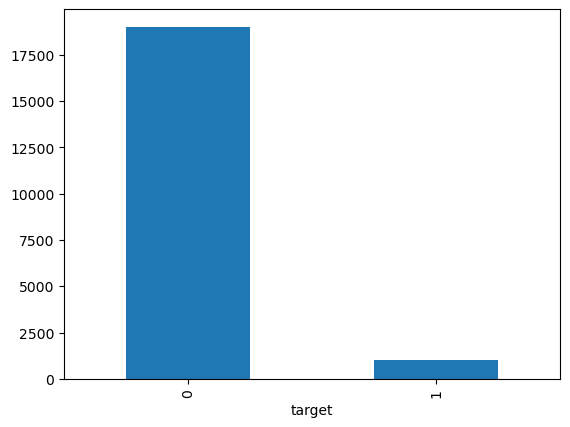

In [205]:
class_counts = df['target'].value_counts()

class_counts.plot(kind='bar')

In [206]:
from imblearn.over_sampling import RandomOverSampler

In [207]:
ros = RandomOverSampler(random_state=42)

In [208]:
X_res, y_res = ros.fit_resample(
    df.drop('target', axis=1),
    df['target']
)

In [209]:
pd.Series(y_res).value_counts()

target
0    19001
1    19001
Name: count, dtype: int64

## Solution:

Check imbalance: df['target'].value_counts() and value_counts(normalize=True)

Visualize: bar chart or pie chart to show imbalance clearly.

Solution 1 — Random Oversampling:

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_res, y_res = ros.fit_resample(df.drop('target', axis=1), df['target'])

Solution 2 — pass class_weight='balanced' when training ML model.

Verify: pd.Series(y_res).value_counts() should show balanced classes.

## Task 15 Schema / Column Validation

**Problem**

Schema or column validation problems occur when a dataset does not follow the expected structure or format. This can happen when columns are missing, extra columns appear unexpectedly, or column names and data types do not match the required schema.

For example, a dataset may be expected to contain columns such as employee_id, name, age, and salary, but instead it may contain misspelled columns like salery or missing columns such as age. In some cases, numeric columns may be stored as strings, creating further inconsistencies.

These issues can break data processing pipelines, cause errors during analysis, and lead to incorrect machine learning results. Schema validation helps ensure that the dataset has the correct columns, correct order, correct data types, and expected structure before further processing or modeling.


In [210]:
df.isnull().mean()

employee_id    0.0
name           0.0
age            0.0
salary         0.0
join_date      0.0
department     0.0
gender         0.0
country        0.0
city           0.0
weight_kg      0.0
is_active      0.0
review         0.0
price          0.0
target         0.0
dtype: float64

In [211]:
cols_to_drop = df.columns[df.isnull().mean() > 0.5].tolist()
cols_to_drop

[]

In [212]:
df.drop(columns=cols_to_drop, inplace=True)

In [213]:
df.drop(columns=cols_to_drop, inplace=True)

In [214]:
expected_cols = ['employee_id', 'name', 'age', 'salary']

In [215]:
missing = set(expected_cols) - set(df.columns)
missing

set()

In [216]:
df.columns

Index(['employee_id', 'name', 'age', 'salary', 'join_date', 'department',
       'gender', 'country', 'city', 'weight_kg', 'is_active', 'review',
       'price', 'target'],
      dtype='object')

## Solution:

Identify bad columns: df.isnull().mean() to see null percentage per column.

Set threshold: drop columns with > 50% null values.

cols_to_drop = df.columns[df.isnull().mean() > 0.5].tolist()

Drop: df.drop(columns=cols_to_drop, inplace=True)

Validate expected columns: expected_cols = ['employee_id','name','age','salary',...]

Check missing: missing = set(expected_cols) - set(df.columns)

Verify: df.columns to confirm correct schema.